

---

HELP LIB


---



In [6]:
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

def plot_some_data(train_images, train_labels, class_names):
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(train_images[i], cmap=plt.cm.binary)
        plt.xlabel(class_names[train_labels[i]])
    plt.show()


def plot_some_predictions(test_images, test_labels, predictions, class_names, num_rows=5, num_cols=3):
    # Plot the first X test images, their predicted labels, and the true labels.
    # Color correct predictions in blue and incorrect predictions in red.
    num_images = num_rows*num_cols
    plt.figure(figsize=(2*2*num_cols, 2*num_rows))
    for i in range(num_images):
        plt.subplot(num_rows, 2*num_cols, 2*i+1)
        plot_image(i, predictions[i], test_labels, class_names, test_images)
        plt.subplot(num_rows, 2*num_cols, 2*i+2)
        plot_value_array(i, predictions[i], test_labels)
    plt.tight_layout()
    plt.show()




def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

def plot_image(i, predictions_array, true_label, class_names, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)




---


SGD ALGORITHM




---



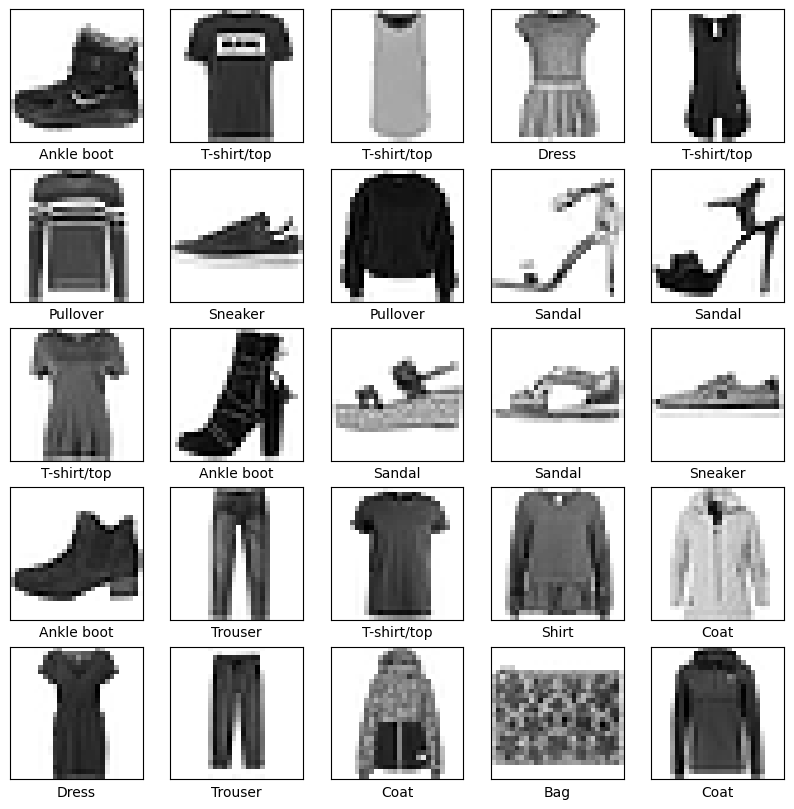

Epoch 1/400
1875/1875 [==============================] - 9s 5ms/step - loss: 0.7340 - accuracy: 0.7657 - val_loss: 0.5763 - val_accuracy: 0.8027
Epoch 2/400
1875/1875 [==============================] - 7s 4ms/step - loss: 0.5180 - accuracy: 0.8229 - val_loss: 0.5379 - val_accuracy: 0.8079
Epoch 3/400
1875/1875 [==============================] - 8s 4ms/step - loss: 0.4720 - accuracy: 0.8364 - val_loss: 0.4871 - val_accuracy: 0.8287
Epoch 4/400
1875/1875 [==============================] - 8s 4ms/step - loss: 0.4469 - accuracy: 0.8446 - val_loss: 0.4616 - val_accuracy: 0.8379
Epoch 5/400
1875/1875 [==============================] - 8s 4ms/step - loss: 0.4281 - accuracy: 0.8512 - val_loss: 0.4498 - val_accuracy: 0.8401
Epoch 6/400
1875/1875 [==============================] - 8s 4ms/step - loss: 0.4132 - accuracy: 0.8561 - val_loss: 0.4485 - val_accuracy: 0.8379
Epoch 7/400
1875/1875 [==============================] - 8s 4ms/step - loss: 0.4002 - accuracy: 0.8601 - val_loss: 0.4387 - val_ac

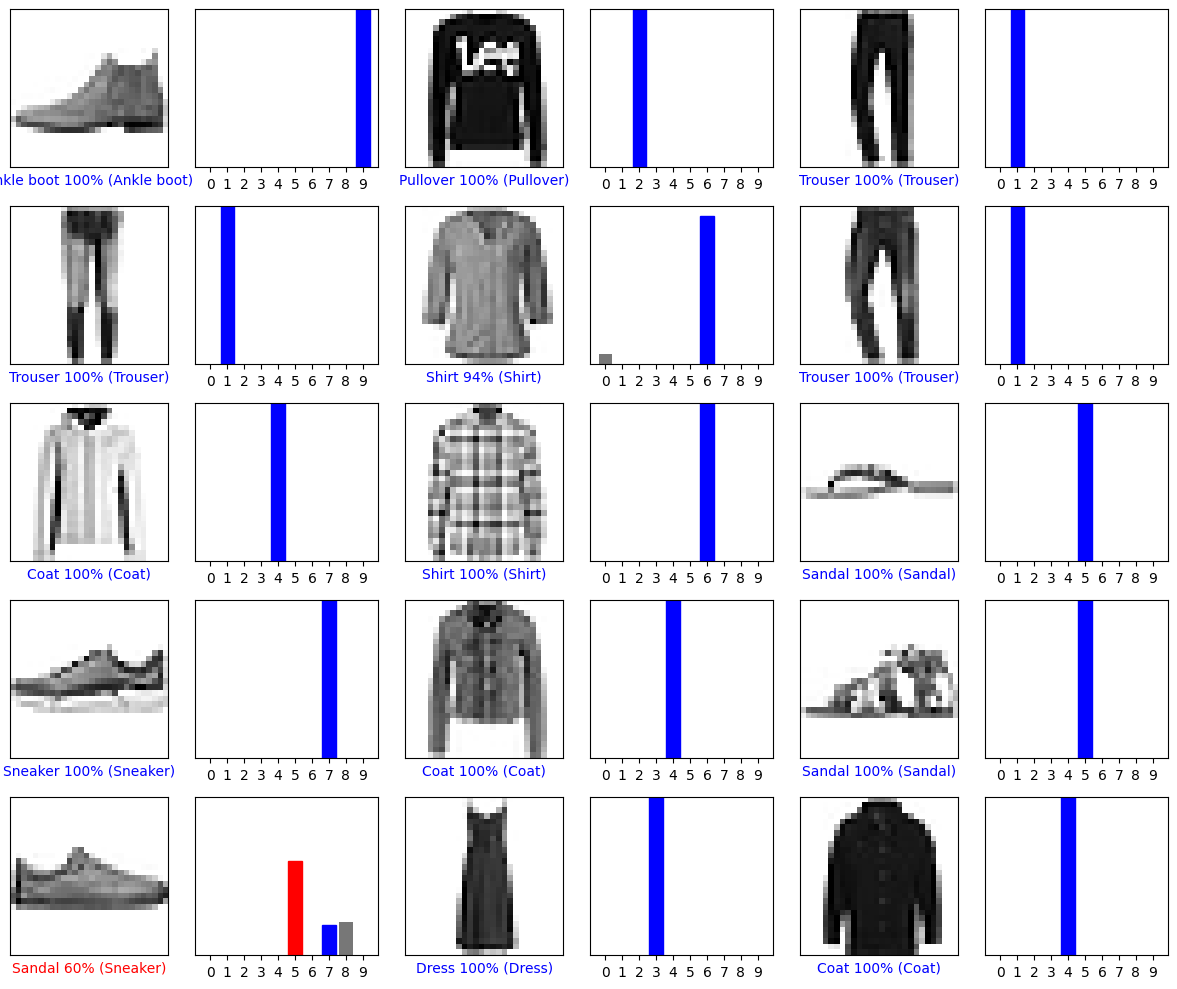

In [ ]:
from __future__ import absolute_import, division, print_function, unicode_literals

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Scale these values to a range of 0 to 1 before feeding them to the neural network model.
    ### YOUR CODE HERE

train_images = train_images / 255.0
test_images = test_images / 255.0

plot_some_data(train_images, train_labels, class_names)

# Build the model of dense neural network
# Building the neural network requires configuring the layers of the model, then compiling the model.
# Define the input layer based on the shape of the images
# Then define two dense layers.
# The hidden layer with 128 neurons and RELU activation
# The output layer with 10 neurons and linear activation.

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10)

])


model.compile(optimizer='sgd',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

#Train the model
# Training the neural network model requires the following steps:

#   1. Feed the training data to the model. In this example, the training data is in the train_images and train_labels arrays.
#   2. The model learns to associate images and labels.
#   3. You ask the model to make predictions about a test set—in this example, the test_images array.
#   4. Verify that the predictions match the labels from the test_labels array.

model.fit(train_images, train_labels, epochs=400, validation_data=(test_images, test_labels))

# Evaluate accuracy
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

# Make predictions
# With the model trained, you can use it to make predictions about some images.
# The model's linear outputs, logits.
# Attach a softmax layer to convert the logits to probabilities, which are easier to interpret.
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])

predictions = probability_model.predict(test_images)

plot_some_predictions(test_images, test_labels, predictions, class_names, num_rows=5, num_cols=3)




---

RMSPROP ALGORITHM

---



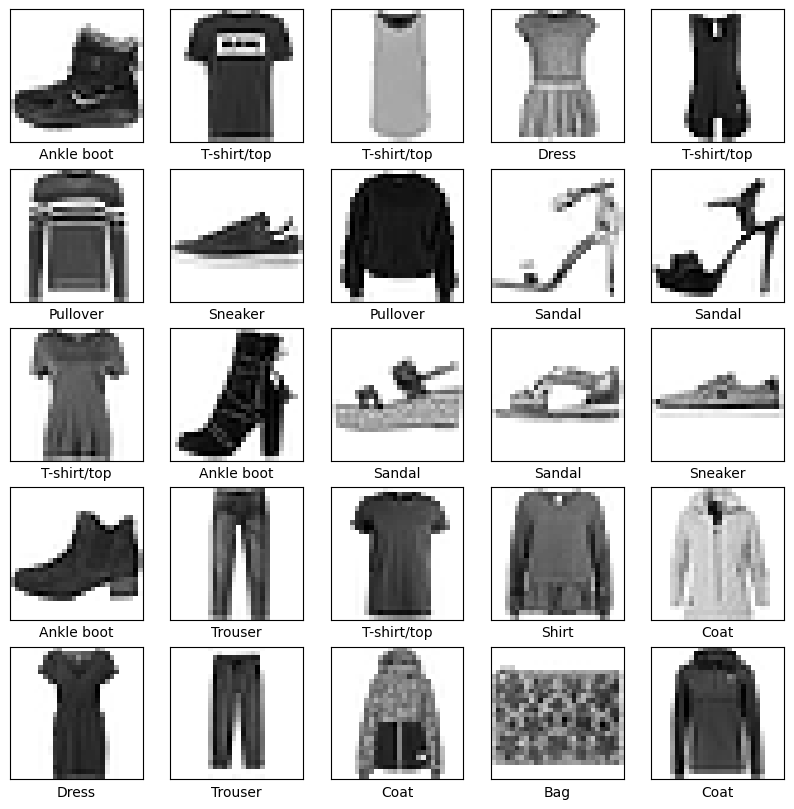

Epoch 1/400
1875/1875 [==============================] - 11s 6ms/step - loss: 0.5092 - accuracy: 0.8190 - val_loss: 0.4566 - val_accuracy: 0.8409
Epoch 2/400
1875/1875 [==============================] - 9s 5ms/step - loss: 0.3770 - accuracy: 0.8653 - val_loss: 0.3929 - val_accuracy: 0.8569
Epoch 3/400
1875/1875 [==============================] - 10s 6ms/step - loss: 0.3440 - accuracy: 0.8768 - val_loss: 0.3838 - val_accuracy: 0.8702
Epoch 4/400
1875/1875 [==============================] - 10s 5ms/step - loss: 0.3248 - accuracy: 0.8846 - val_loss: 0.3848 - val_accuracy: 0.8687
Epoch 5/400
1875/1875 [==============================] - 9s 5ms/step - loss: 0.3124 - accuracy: 0.8881 - val_loss: 0.3497 - val_accuracy: 0.8833
Epoch 6/400
1875/1875 [==============================] - 9s 5ms/step - loss: 0.3012 - accuracy: 0.8939 - val_loss: 0.3720 - val_accuracy: 0.8741
Epoch 7/400
1875/1875 [==============================] - 10s 5ms/step - loss: 0.2952 - accuracy: 0.8958 - val_loss: 0.4082 - va

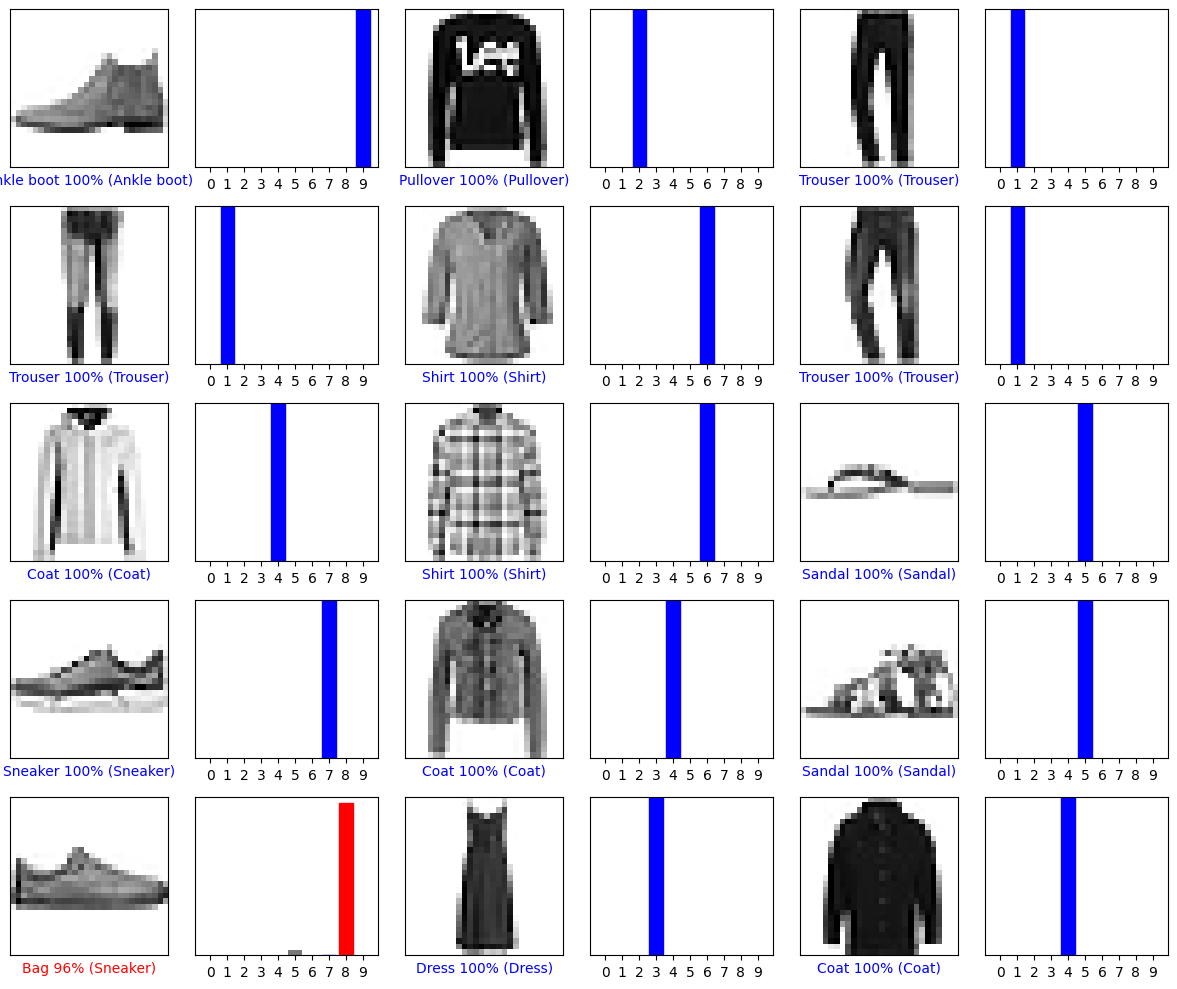

In [ ]:
from __future__ import absolute_import, division, print_function, unicode_literals

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Scale these values to a range of 0 to 1 before feeding them to the neural network model.
    ### YOUR CODE HERE

train_images = train_images / 255.0
test_images = test_images / 255.0

plot_some_data(train_images, train_labels, class_names)

# Build the model of dense neural network
# Building the neural network requires configuring the layers of the model, then compiling the model.
# Define the input layer based on the shape of the images
# Then define two dense layers.
# The hidden layer with 128 neurons and RELU activation
# The output layer with 10 neurons and linear activation.

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10)

])


model.compile(optimizer='rmsprop',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

#Train the model
# Training the neural network model requires the following steps:

#   1. Feed the training data to the model. In this example, the training data is in the train_images and train_labels arrays.
#   2. The model learns to associate images and labels.
#   3. You ask the model to make predictions about a test set—in this example, the test_images array.
#   4. Verify that the predictions match the labels from the test_labels array.

model.fit(train_images, train_labels, epochs=400, validation_data=(test_images, test_labels))

# Evaluate accuracy
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

# Make predictions
# With the model trained, you can use it to make predictions about some images.
# The model's linear outputs, logits.
# Attach a softmax layer to convert the logits to probabilities, which are easier to interpret.
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])

predictions = probability_model.predict(test_images)

plot_some_predictions(test_images, test_labels, predictions, class_names, num_rows=5, num_cols=3)




---

Testing Plotting Acurracies

---



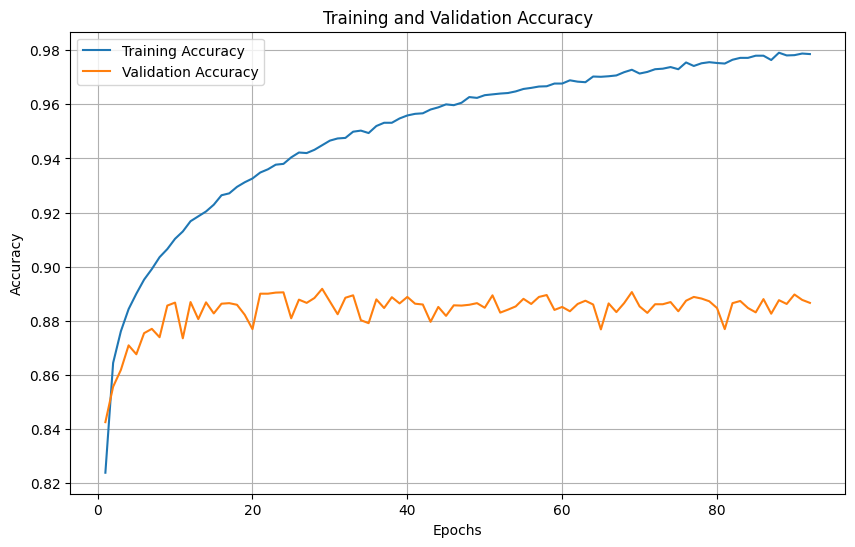

In [4]:
import matplotlib.pyplot as plt

epochs = list(range(1, 93))
training_accuracy = [
    0.8238, 0.8644, 0.8761, 0.8843, 0.8900, 0.8952, 0.8991, 0.9035, 0.9065, 0.9103,
    0.9130, 0.9168, 0.9186, 0.9204, 0.9229, 0.9264, 0.9271, 0.9295, 0.9312, 0.9326,
    0.9348, 0.9360, 0.9377, 0.9380, 0.9404, 0.9422, 0.9420, 0.9432, 0.9449, 0.9466,
    0.9474, 0.9476, 0.9499, 0.9503, 0.9494, 0.9520, 0.9532, 0.9532, 0.9548, 0.9559,
    0.9565, 0.9567, 0.9581, 0.9589, 0.9600, 0.9597, 0.9606, 0.9627, 0.9624, 0.9634,
    0.9637, 0.9640, 0.9642, 0.9648, 0.9657, 0.9661, 0.9666, 0.9667, 0.9677, 0.9677,
    0.9689, 0.9684, 0.9682, 0.9703, 0.9702, 0.9704, 0.9707, 0.9719, 0.9728, 0.9714,
    0.9720, 0.9730, 0.9732, 0.9738, 0.9730, 0.9755, 0.9742, 0.9752, 0.9756, 0.9753,
    0.9751, 0.9765, 0.9772, 0.9772, 0.9780, 0.9780, 0.9764, 0.9791, 0.9781, 0.9782,
    0.9788, 0.9786
]
validation_accuracy = [
    0.8425, 0.8556, 0.8618, 0.8709, 0.8676, 0.8754, 0.8770, 0.8739, 0.8856, 0.8867,
    0.8735, 0.8869, 0.8806, 0.8868, 0.8827, 0.8863, 0.8865, 0.8859, 0.8822, 0.8769,
    0.8900, 0.8900, 0.8904, 0.8905, 0.8809, 0.8878, 0.8866, 0.8884, 0.8918, 0.8871,
    0.8824, 0.8885, 0.8894, 0.8802, 0.8791, 0.8879, 0.8847, 0.8887, 0.8864, 0.8888,
    0.8863, 0.8860, 0.8796, 0.8851, 0.8818, 0.8857, 0.8856, 0.8859, 0.8865, 0.8848,
    0.8894, 0.8830, 0.8841, 0.8853, 0.8881, 0.8862, 0.8888, 0.8895, 0.8840, 0.8851,
    0.8835, 0.8862, 0.8874, 0.8860, 0.8768, 0.8864, 0.8832, 0.8865, 0.8906, 0.8853,
    0.8829, 0.8861, 0.8861, 0.8869, 0.8835, 0.8874, 0.8888, 0.8882, 0.8872, 0.8847,
    0.8769, 0.8865, 0.8873, 0.8847, 0.8831, 0.8880, 0.8826, 0.8876, 0.8862, 0.8897,
    0.8877, 0.8866
]

plt.figure(figsize=(10, 6))
plt.plot(epochs, training_accuracy, label='Training Accuracy')
plt.plot(epochs, validation_accuracy, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()




---

Αλλάξαμε την αρχιτεκτονική του δικτύου. Θα χρειαστεί να
μετασχηματίσουμε τις διαστάσεις των δεδομένων μας από #images × height × width σε #images × height × width × #channels, όπου #images είναι ο αριθμός των εικόνων και #channels=1 είναι ο αριθμός των καναλιών. Επίσης, αλλάξαμε το epoch από 400 σε 50 για να τελειώνει πιο γρήγορα η εκπαίδευση και χρησιμοποιήστε τον adam optimizer.


---



Epoch 1/50
1875/1875 [==============================] - 307s 163ms/step - loss: 0.4161 - accuracy: 0.8468 - val_loss: 0.2995 - val_accuracy: 0.8879
Epoch 2/50
1875/1875 [==============================] - 303s 161ms/step - loss: 0.2515 - accuracy: 0.9072 - val_loss: 0.2779 - val_accuracy: 0.8979
Epoch 3/50
1875/1875 [==============================] - 309s 165ms/step - loss: 0.2117 - accuracy: 0.9215 - val_loss: 0.2333 - val_accuracy: 0.9168
Epoch 4/50
1875/1875 [==============================] - 296s 158ms/step - loss: 0.1816 - accuracy: 0.9341 - val_loss: 0.2196 - val_accuracy: 0.9228
Epoch 5/50
1875/1875 [==============================] - 288s 153ms/step - loss: 0.1568 - accuracy: 0.9416 - val_loss: 0.2238 - val_accuracy: 0.9221
Epoch 6/50
1875/1875 [==============================] - 300s 160ms/step - loss: 0.1369 - accuracy: 0.9493 - val_loss: 0.2302 - val_accuracy: 0.9226
Epoch 7/50
1875/1875 [==============================] - 288s 153ms/step - loss: 0.1195 - accuracy: 0.9559 - val_

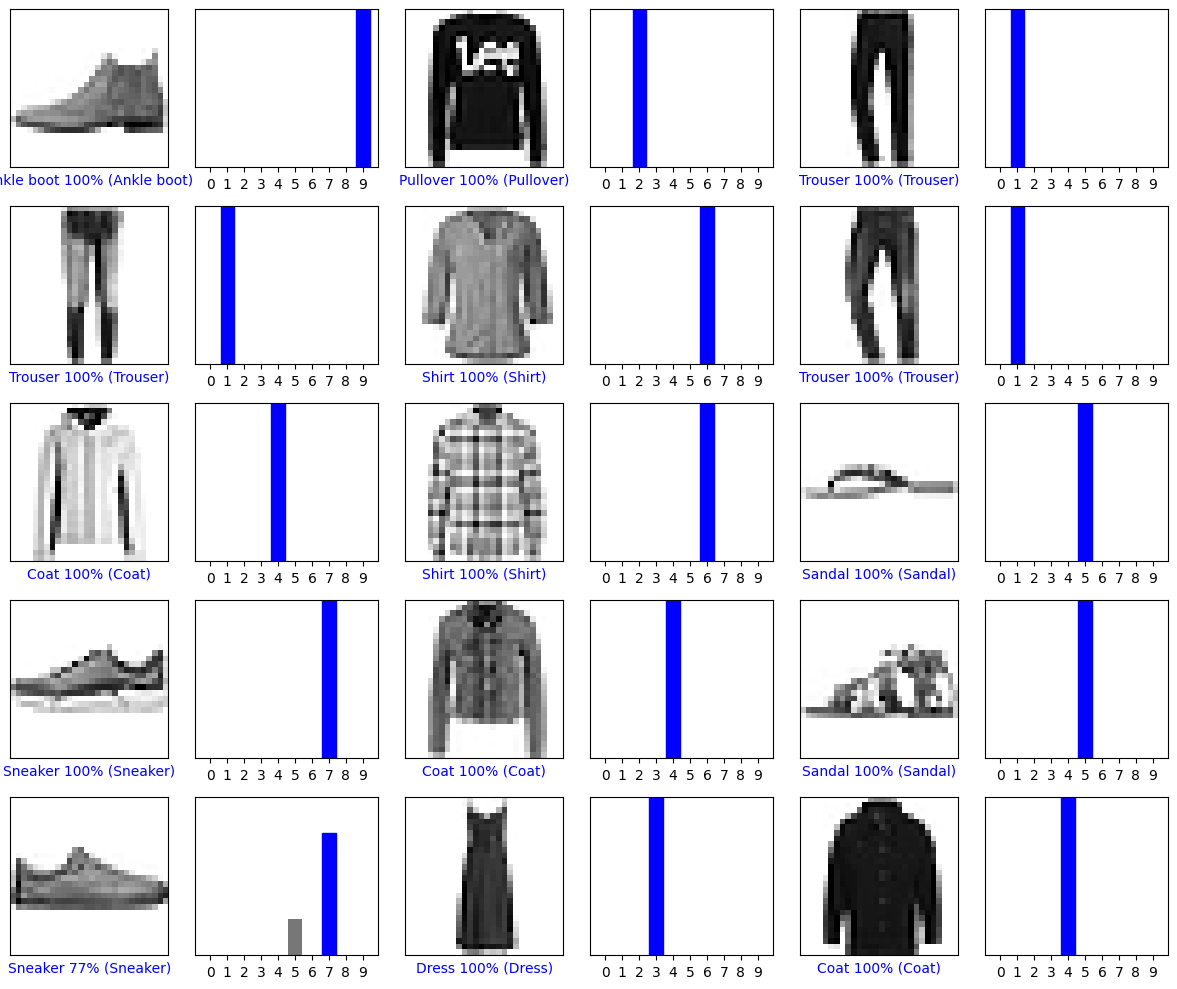

In [11]:
from __future__ import absolute_import, division, print_function, unicode_literals

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt


fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Scale these values to a range of 0 to 1 before feeding them to the neural network model.

train_images = train_images/255.0  # normalize
test_images =  test_images/255.0 # normalize

train_images_reshaped = train_images.reshape(train_images.shape[0], 28, 28, 1) # reshape to mum_train_images X height X width X channels, where channels = 1
test_images_reshaped = test_images.reshape(test_images.shape[0], 28, 28, 1) # reshape


# Build the model
# Building the neural network requires configuring the layers of the model, then compiling the model.

model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), strides = 1, activation = 'relu', input_shape=(28, 28, 1), padding = 'same'),
    keras.layers.Conv2D(32, (3, 3), strides = 1, activation = 'relu', padding = 'same'),
    keras.layers.MaxPooling2D((2, 2), padding = 'valid'),

    keras.layers.Conv2D(64, (3, 3), strides = 1, activation = 'relu', padding ='same'),
    keras.layers.Conv2D(64, (3, 3), strides = 1, activation = 'relu', padding ='same'),
    keras.layers.MaxPooling2D((2, 2), padding = 'valid'),

    keras.layers.Conv2D(128, (3, 3), strides = 1, activation = 'relu', padding ='same'),
    keras.layers.Conv2D(128, (3, 3), strides = 1, activation = 'relu', padding ='same'),
    keras.layers.MaxPooling2D((2, 2), padding = 'valid'),

    keras.layers.Flatten(),
    keras.layers.Dense(200, activation ='relu'),
    keras.layers.Dense(10)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

#Train the model
# Training the neural network model requires the following steps:

#   1. Feed the training data to the model. In this example, the training data is in the train_images and train_labels arrays.
#   2. The model learns to associate images and labels.
#   3. You ask the model to make predictions about a test set—in this example, the test_images array.
#   4. Verify that the predictions match the labels from the test_labels array.

model.fit(train_images_reshaped, train_labels, epochs=50, validation_data=(test_images_reshaped, test_labels))

# Evaluate accuracy
test_loss, test_acc = model.evaluate(test_images_reshaped,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

# Make predictions
# With the model trained, you can use it to make predictions about some images.
# The model's linear outputs, logits.
# Attach a softmax layer to convert the logits to probabilities, which are easier to interpret.
probability_model = tf.keras.Sequential([model,
                                         tf.keras.layers.Softmax()])

predictions = probability_model.predict(test_images_reshaped)

plot_some_predictions(test_images, test_labels, predictions, class_names, num_rows=5, num_cols=3)









---

Μερικές εκτελέσεις βρίσκονται σε άλλα αρχεία και κάποιες δεν υπάρχουν γιατί
είναι αρκετά παρόμοιες με εκτελέσεις παραπάνω.


---

